# 📱 Smartphone Upgrade Probability Model

*A theoretical behavioral-economics simulation of how environmental trade-in framing may
influence smartphone upgrade probability through **moral licensing**, compared across the
United States and India.*

> ⚠️ **This is a simulation, not an empirical study.** The parameters are stylized and are
> meant to generate *testable predictions*, not to forecast real individual behavior. See the
> **Limitations** section at the bottom.

This notebook recreates the baseline model, reproduces the figures, and lets you adjust the
key behavioral parameters. All of the math lives in [`model.py`](../model.py); the chart
functions live in [`figures.py`](../figures.py).

## Research question

Manufacturers routinely frame smartphone trade-in programs as *environmentally responsible*.
Does that positive framing actually **reduce** upgrading — or does it **morally license**
consumers to upgrade *sooner* by signalling that the environmental cost has already been
handled?

We compare three information conditions:

| Condition | Description |
|---|---|
| **Control** | No environmental framing |
| **Positive framing** | Manufacturer presents the trade-in as "green" |
| **Accurate disclosure** | Consumer receives *specific* environmental-cost information |

## The model

$$
P(\text{upgrade}\mid f) = \Phi\!\Big[\, v(C/Y) \;-\; \delta\,\kappa \;+\; \gamma\,\phi(f)\,(1-V)\,(1-\omega) \,\Big]
$$

| Symbol | Meaning |
|---|---|
| $C/Y$ | trade-in credit-to-income ratio |
| $v(C/Y)$ | concave utility from the trade-in credit (scaled by present bias $\beta$) |
| $\kappa$ | baseline resistance to upgrading (weighted by discount factor $\delta$) |
| $\gamma$ | moral-licensing effect size |
| $\phi(f)$ | framing-condition effect: $0$ (control), $+1$ (positive), or a logistic of disclosure specificity |
| $V$ | claim verifiability — verifiable claims leave *less* room to license |
| $\omega$ | environmental self-identity — strong identity *resists* licensing |
| $\Phi$ | standard normal CDF |

The **moral-licensing term** $\gamma\,\phi(f)\,(1-V)\,(1-\omega)$ is the heart of the story:
positive "green" framing ($\phi=+1$) pushes the latent score up; accurate, *specific*
disclosure flips $\phi$ negative and pushes it down.

In [1]:
# Make the package importable from the notebooks/ subfolder.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

import model
import figures

markets = model.load_parameters()
list(markets)

['United States', 'India']

## Baseline parameters

Loaded from [`data/parameters.csv`](../data/parameters.csv).

In [2]:
params_df = pd.read_csv(model.DEFAULT_PARAMS_PATH).set_index("market")
params_df

,claim_verifiability,env_self_identity,moral_licensing_effect,present_bias,discount_factor,baseline_resistance,specificity_threshold,credit_to_income
market,,,,,,,,
United States,0.3,0.45,0.9,1.0,0.85,1.0,0.5,0.08
India,0.2,0.35,1.1,1.1,0.80,1.1,0.5,0.30


## Baseline simulation

Predicted upgrade probability for each market under each framing condition, plus the
**moral-licensing gap** — how much positive framing raises the upgrade probability relative
to the control.

In [3]:
rows = []
for name, p in markets.items():
    probs = model.upgrade_probabilities(p)
    rows.append({
        "Market": name,
        "Control": probs["control"],
        "Positive framing": probs["positive"],
        "Accurate disclosure": probs["disclosure"],
        "Licensing gap (Positive − Control)": model.licensing_probability_gap(p),
    })

baseline = pd.DataFrame(rows).set_index("Market")
baseline.style.format("{:.1%}")

,Control,Positive framing,Accurate disclosure,Licensing gap (Positive − Control)
Market,,,,
United States,44.3%,58.1%,33.1%,13.7%
India,73.4%,88.5%,55.6%,15.0%


Two things stand out:

1. **Positive framing raises the predicted upgrade probability** in both markets — the moral
   licensing effect.
2. **Accurate, specific disclosure pushes it back below the control** — confronting a concrete
   environmental cost suppresses upgrading.

India shows a *larger* licensing swing because the trade-in credit is a bigger share of income,
claims are harder to verify, and environmental self-identity is lower in this stylized baseline.

## Chart 1 — Upgrade probability by framing condition and market

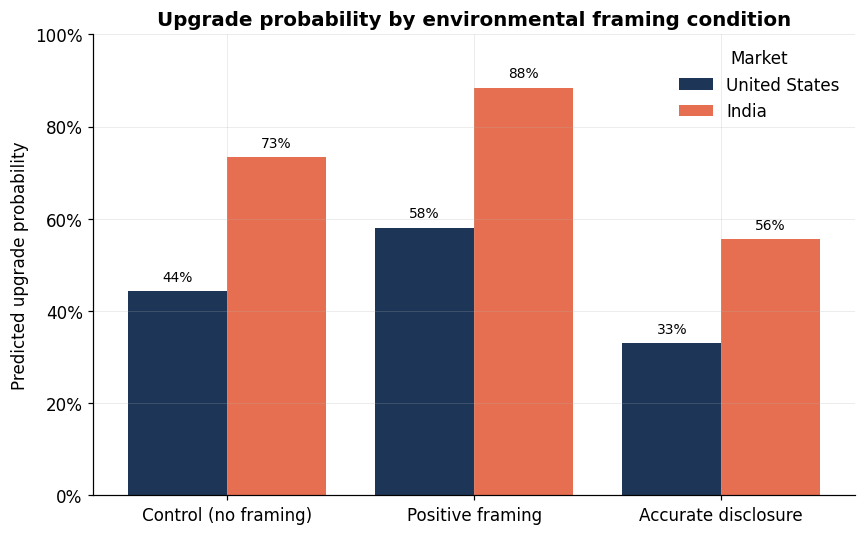

In [4]:
fig = figures.chart_framing_comparison(markets); plt.show()

## Chart 2 — Moral-licensing strength vs. claim verifiability

The licensing term $\gamma\,(1-V)\,(1-\omega)$ shrinks to zero as claims become fully
verifiable. When a "green" claim can be checked, it can no longer license an upgrade.

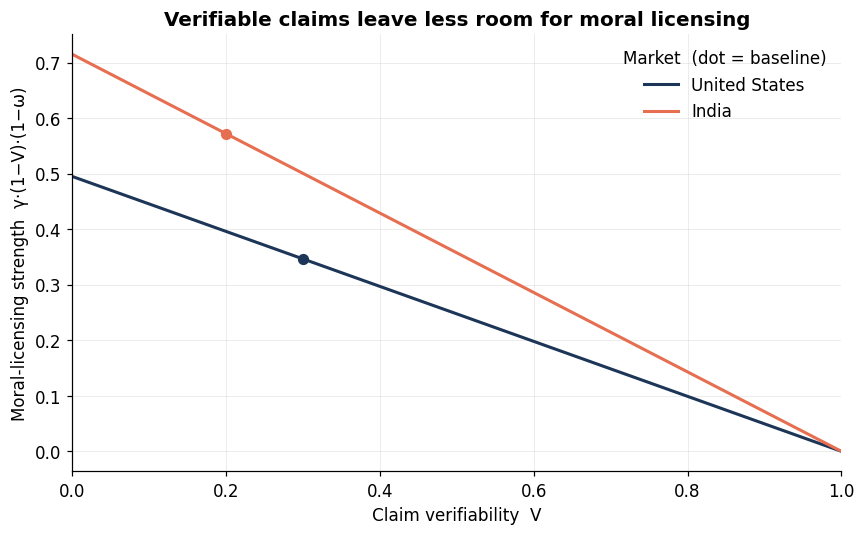

In [5]:
fig = figures.chart_licensing_vs_verifiability(markets); plt.show()

## Chart 3 — Upgrade probability across credit-to-income ratios

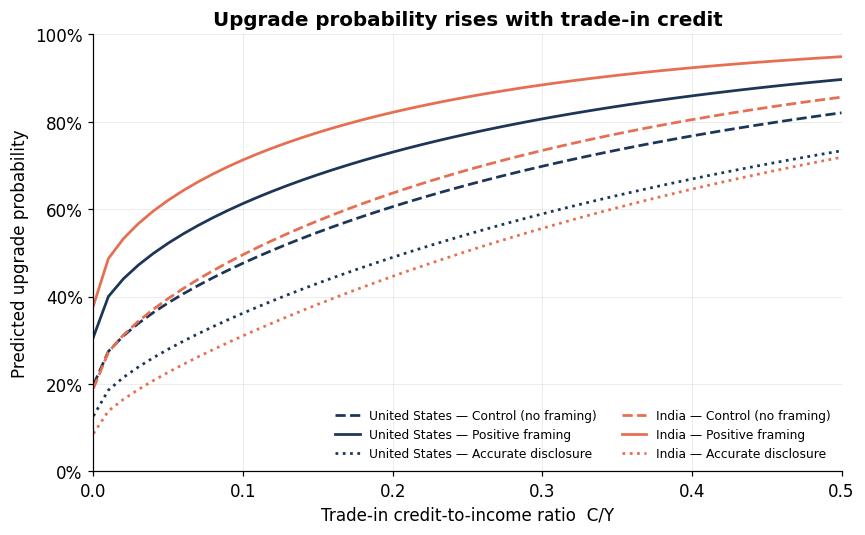

In [6]:
fig = figures.chart_upgrade_vs_credit(markets); plt.show()

## Chart 4 — Accurate-disclosure effect across information specificity

As the disclosure becomes more *specific* (moving right past the threshold $s^*$), it stops
licensing and starts **suppressing** upgrades — the curve crosses below each market's control
level (dotted line).

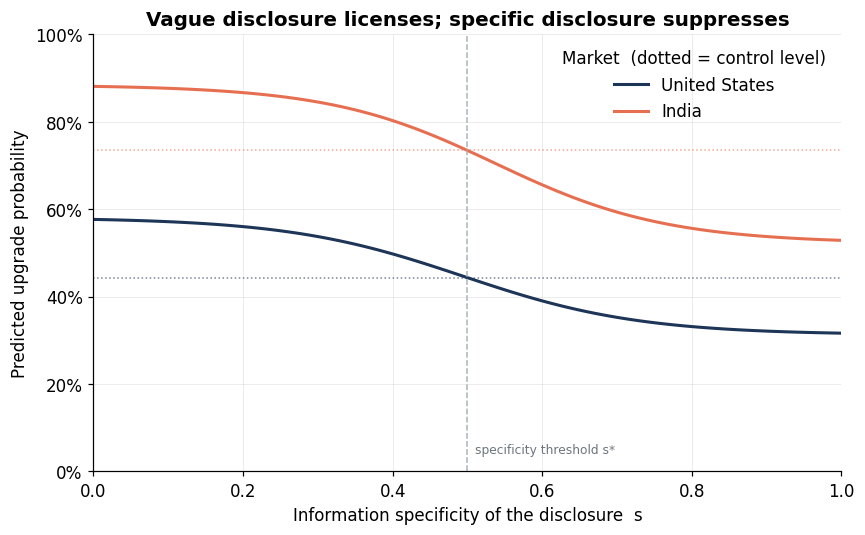

In [7]:
fig = figures.chart_disclosure_specificity(markets); plt.show()

## Chart 5 (optional) — Sensitivity to present bias

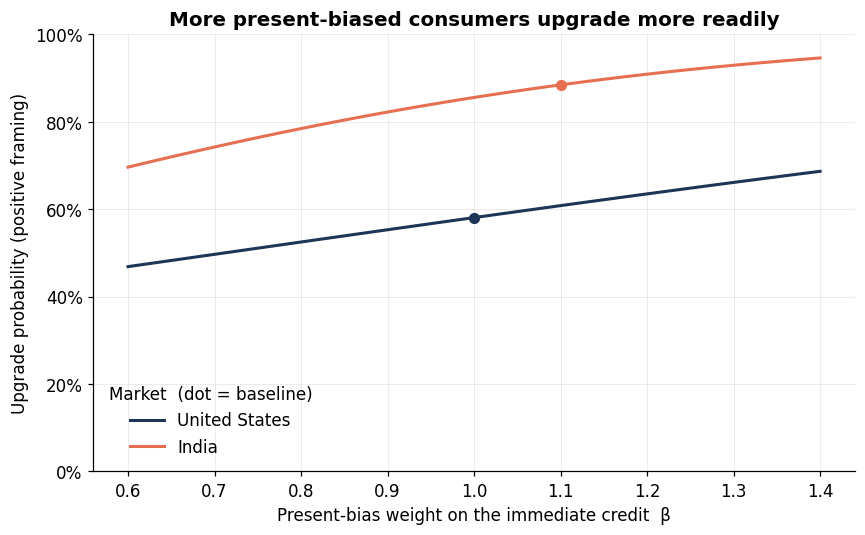

In [8]:
fig = figures.chart_present_bias_sensitivity(markets); plt.show()

## Optional — interactive sliders

If you have `ipywidgets` installed (`pip install ipywidgets`), run the cell below to explore
the model interactively. For a fuller dashboard, run the Streamlit app instead:

```bash
streamlit run app.py
```

In [9]:
try:
    from ipywidgets import interact, FloatSlider, Dropdown

    def explore(market="United States", credit_to_income=0.08,
                claim_verifiability=0.30, env_self_identity=0.45,
                moral_licensing_effect=0.90, specificity=0.80):
        base = markets[market]
        p = model.MarketParameters(
            market=market,
            claim_verifiability=claim_verifiability,
            env_self_identity=env_self_identity,
            moral_licensing_effect=moral_licensing_effect,
            present_bias=base.present_bias,
            discount_factor=base.discount_factor,
            baseline_resistance=base.baseline_resistance,
            specificity_threshold=base.specificity_threshold,
            credit_to_income=credit_to_income,
        )
        probs = {c: model.upgrade_probability(p, c, specificity=specificity)
                 for c in model.CONDITIONS}
        for c in model.CONDITIONS:
            print(f"{model.CONDITION_LABELS[c]:<22} {probs[c]:6.1%}")
        print(f"\nMoral-licensing gap (Positive − Control): "
              f"{probs['positive'] - probs['control']:+.1%}")

    interact(
        explore,
        market=Dropdown(options=list(markets), value="United States"),
        credit_to_income=FloatSlider(min=0.0, max=0.5, step=0.01, value=0.08),
        claim_verifiability=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.30),
        env_self_identity=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.45),
        moral_licensing_effect=FloatSlider(min=0.0, max=2.0, step=0.05, value=0.90),
        specificity=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.80),
    )
except ImportError:
    print("ipywidgets not installed — skipping interactive sliders. "
          "Install with: pip install ipywidgets")

ipywidgets not installed — skipping interactive sliders. Install with: pip install ipywidgets


## Limitations & future research

This is a **theoretical simulation**, not a validated empirical study. Read every number as
"what the model implies under these assumptions," never as a measured fact.

- **Parameter values are stylized** and difficult to validate without survey or field data.
- **Market-level parameters hide individual heterogeneity** — real consumers differ widely.
- The model **simplifies** a complex decision into a single latent score.
- **Claim verifiability and environmental self-identity are hard to measure** precisely.
- **Disclosure effects depend on wording, trust, numeracy, and culture** that the model abstracts away.

**Future directions (V2):** a randomized survey experiment; real consumer-response data;
comparing Apple vs. Samsung trade-in language; expanding beyond the US and India; Monte Carlo
confidence intervals; and a disclosure-requirement policy simulator.

---

### Connection to the research paper

This notebook operationalizes the paper's central argument — that positive environmental
trade-in framing can **morally license** upgrading rather than discourage it — as a transparent,
reproducible model. The goal is to turn a written theory into something a reviewer can run,
inspect, and stress-test. Treat the outputs as **predictions to be tested**, not conclusions.